In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [8]:
df = pd.read_csv("gci_cleaned.csv", sep=";")

print("Dataset loaded successfully.")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

Dataset loaded successfully.
Number of rows: 52
Number of columns: 7


In [9]:
df.head()

,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,UNIT_MEASURE_LABEL,YEAR,VALUE
0,ZAF,South Africa,ITU_GCI_CDS_CYB_PROF_TRAIN,Training for Cybersecurity Professionals - CDS...,0-1 scale,2020,0.799944
1,ZAF,South Africa,ITU_GCI_CDS_CYB_PROF_TRAIN,Training for Cybersecurity Professionals - CDS...,0-1 scale,2024,0.669010
2,ZAF,South Africa,ITU_GCI_CDS_GOV_ACAD,Educational programs or academic curricula in ...,0-1 scale,2020,0.708929
3,ZAF,South Africa,ITU_GCI_CDS_GOV_ACAD,Educational programs or academic curricula in ...,0-1 scale,2024,0.634677
4,ZAF,South Africa,ITU_GCI_CDS_GOV_MCNSM,Government Incentive Mechanisms - CDS6 (ITU GCI),0-1 scale,2020,0.492857


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   REF_AREA            52 non-null     object 
 1   REF_AREA_LABEL      52 non-null     object 
 2   INDICATOR           52 non-null     object 
 3   INDICATOR_LABEL     52 non-null     object 
 4   UNIT_MEASURE_LABEL  52 non-null     object 
 5   YEAR                52 non-null     int64  
 6   VALUE               51 non-null     float64
dtypes: float64(1), int64(1), object(5)
memory usage: 3.0+ KB


In [11]:
print("Country names:")
print(df["REF_AREA_LABEL"].unique())

print("\nCountry codes:")
print(df["REF_AREA"].unique())

Country names:
['South Africa']

Country codes:
['ZAF']


In [12]:
print("Available years:")
print(sorted(df["YEAR"].unique()))

Available years:
[np.int64(2020), np.int64(2024)]


In [13]:
print("Number of unique GCI indicators:")
print(df["INDICATOR"].nunique())

Number of unique GCI indicators:
26


In [14]:
indicators = df[["INDICATOR", "INDICATOR_LABEL"]].drop_duplicates()

print(indicators.to_string(index=False))

                 INDICATOR                                                                                         INDICATOR_LABEL
ITU_GCI_CDS_CYB_PROF_TRAIN                                               Training for Cybersecurity Professionals - CDS2 (ITU GCI)
      ITU_GCI_CDS_GOV_ACAD                            Educational programs or academic curricula in cybersecurity - CDS3 (ITU GCI)
     ITU_GCI_CDS_GOV_MCNSM                                                        Government Incentive Mechanisms - CDS6 (ITU GCI)
   ITU_GCI_CDS_NAT_CYB_IND                                                        National cybersecurity industry - CDS5 (ITU GCI)
   ITU_GCI_CDS_PUB_CYB_AWE                                               Public cybersecurity awareness campaigns - CDS1 (ITU GCI)
      ITU_GCI_CDS_RND_PROG                                      Research and development programs on cybersecurity -CDS4 (ITU GCI)
         ITU_GCI_CDS_SCORE                                                         

In [15]:
indicators = df[["INDICATOR", "INDICATOR_LABEL"]].drop_duplicates()

print(indicators.to_string(index=False))

                 INDICATOR                                                                                         INDICATOR_LABEL
ITU_GCI_CDS_CYB_PROF_TRAIN                                               Training for Cybersecurity Professionals - CDS2 (ITU GCI)
      ITU_GCI_CDS_GOV_ACAD                            Educational programs or academic curricula in cybersecurity - CDS3 (ITU GCI)
     ITU_GCI_CDS_GOV_MCNSM                                                        Government Incentive Mechanisms - CDS6 (ITU GCI)
   ITU_GCI_CDS_NAT_CYB_IND                                                        National cybersecurity industry - CDS5 (ITU GCI)
   ITU_GCI_CDS_PUB_CYB_AWE                                               Public cybersecurity awareness campaigns - CDS1 (ITU GCI)
      ITU_GCI_CDS_RND_PROG                                      Research and development programs on cybersecurity -CDS4 (ITU GCI)
         ITU_GCI_CDS_SCORE                                                         

In [16]:


df["REF_AREA"] = df["REF_AREA"].str.strip()
df["REF_AREA_LABEL"] = df["REF_AREA_LABEL"].str.strip()
df["INDICATOR"] = df["INDICATOR"].str.strip()
df["INDICATOR_LABEL"] = df["INDICATOR_LABEL"].str.replace(r"\s+", " ", regex=True).str.strip()
df["UNIT_MEASURE_LABEL"] = df["UNIT_MEASURE_LABEL"].str.replace(r"\s+", " ", regex=True).str.strip()

print("Text cleaning completed successfully.")

Text cleaning completed successfully.


In [17]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
REF_AREA              0
REF_AREA_LABEL        0
INDICATOR             0
INDICATOR_LABEL       0
UNIT_MEASURE_LABEL    0
YEAR                  0
VALUE                 1
dtype: int64


In [18]:
missing_values = df[df["VALUE"].isna()]

print("Records with missing values:")
print(missing_values.to_string(index=False))

Records with missing values:
REF_AREA REF_AREA_LABEL              INDICATOR                         INDICATOR_LABEL UNIT_MEASURE_LABEL  YEAR  VALUE
     ZAF   South Africa ITU_GCI_TECH_CHLD_PROT Child Online Protection - TS4 (ITU GCI)          0-1 scale  2024    NaN


In [19]:
print("Descriptive statistics for GCI values:")
print(df["VALUE"].describe())

Descriptive statistics for GCI values:
count    51.000000
mean      6.874204
std      15.288730
min       0.302903
25%       0.778820
50%       0.954104
75%       1.000000
max      78.362604
Name: VALUE, dtype: float64


In [20]:
comparison = df.pivot_table(
    index=["INDICATOR", "INDICATOR_LABEL", "UNIT_MEASURE_LABEL"],
    columns="YEAR",
    values="VALUE",
    aggfunc="first"
).reset_index()

comparison["CHANGE_2020_2024"] = comparison[2024] - comparison[2020]

print("2020 vs 2024 comparison:")
print(comparison.to_string(index=False))

2020 vs 2024 comparison:
                 INDICATOR                                                                                         INDICATOR_LABEL UNIT_MEASURE_LABEL      2020      2024  CHANGE_2020_2024
ITU_GCI_CDS_CYB_PROF_TRAIN                                               Training for Cybersecurity Professionals - CDS2 (ITU GCI)          0-1 scale  0.799944  0.669010         -0.130934
      ITU_GCI_CDS_GOV_ACAD                            Educational programs or academic curricula in cybersecurity - CDS3 (ITU GCI)          0-1 scale  0.708929  0.634677         -0.074251
     ITU_GCI_CDS_GOV_MCNSM                                                        Government Incentive Mechanisms - CDS6 (ITU GCI)          0-1 scale  0.492857  0.513548          0.020691
   ITU_GCI_CDS_NAT_CYB_IND                                                        National cybersecurity industry - CDS5 (ITU GCI)          0-1 scale  1.000000  1.000000          0.000000
   ITU_GCI_CDS_PUB_CYB_AWE         

In [21]:
comparison.to_csv("gci_indicator_comparison.csv", index=False)

print("Indicator comparison saved successfully.")

Indicator comparison saved successfully.


In [22]:
pillar_indicators = [
    "ITU_GCI_LEGL_SCRE",
    "ITU_GCI_TECH_SCORE",
    "ITU_GCI_ORG_SCORE",
    "ITU_GCI_CDS_SCORE",
    "ITU_GCI_COOP_SCORE"
]

pillar_summary = comparison[
    comparison["INDICATOR"].isin(pillar_indicators)
].copy()

print("South Africa GCI Pillar Scores:")
print(
    pillar_summary[
        ["INDICATOR_LABEL", 2020, 2024, "CHANGE_2020_2024"]
    ].to_string(index=False)
)

South Africa GCI Pillar Scores:
                           INDICATOR_LABEL      2020      2024  CHANGE_2020_2024
Capacity Development Score - CDS (ITU GCI) 15.362198 17.560588          2.198390
          Cooperative Score - CS (ITU GCI) 18.838272 16.197870         -2.640401
                Legal Score - LS (ITU GCI) 17.175896 18.897959          1.722064
       Organizational Score - OS (ITU GCI) 15.206407 15.804333          0.597926
            Technical Score - TS (ITU GCI) 15.902916 18.378616          2.475700


In [23]:
pillar_display = pillar_summary[
    ["INDICATOR_LABEL", 2020, 2024, "CHANGE_2020_2024"]
].copy()

pillar_display[2020] = pillar_display[2020].round(2)
pillar_display[2024] = pillar_display[2024].round(2)
pillar_display["CHANGE_2020_2024"] = pillar_display["CHANGE_2020_2024"].round(2)

print(pillar_display.to_string(index=False))

                           INDICATOR_LABEL  2020  2024  CHANGE_2020_2024
Capacity Development Score - CDS (ITU GCI) 15.36 17.56              2.20
          Cooperative Score - CS (ITU GCI) 18.84 16.20             -2.64
                Legal Score - LS (ITU GCI) 17.18 18.90              1.72
       Organizational Score - OS (ITU GCI) 15.21 15.80              0.60
            Technical Score - TS (ITU GCI) 15.90 18.38              2.48


In [24]:
overall_gci = comparison[
    comparison["INDICATOR"] == "ITU_GCI_GCI_OVRL_SCRE"
].copy()

print("South Africa Overall GCI Score:")
print(overall_gci[[2020, 2024, "CHANGE_2020_2024"]].to_string(index=False))

South Africa Overall GCI Score:
     2020      2024  CHANGE_2020_2024
71.018888 78.362604          7.343716


In [25]:
changes = comparison.dropna(subset=["CHANGE_2020_2024"]).copy()

print("Top 5 improvements:")
print(
    changes.sort_values("CHANGE_2020_2024", ascending=False)[
        ["INDICATOR_LABEL", 2020, 2024, "CHANGE_2020_2024"]
    ].head(5).to_string(index=False)
)

print("\nTop 5 declines:")
print(
    changes.sort_values("CHANGE_2020_2024")[
        ["INDICATOR_LABEL", 2020, 2024, "CHANGE_2020_2024"]
    ].head(5).to_string(index=False)
)

Top 5 improvements:
                                     INDICATOR_LABEL      2020      2024  CHANGE_2020_2024
Global Cybersecurity Index - Overall Score (ITU GCI) 71.018888 78.362604          7.343716
                      Technical Score - TS (ITU GCI) 15.902916 18.378616          2.475700
          Capacity Development Score - CDS (ITU GCI) 15.362198 17.560588          2.198390
                          Legal Score - LS (ITU GCI) 17.175896 18.897959          1.722064
                 Organizational Score - OS (ITU GCI) 15.206407 15.804333          0.597926

Top 5 declines:
                                                                                        INDICATOR_LABEL      2020      2024  CHANGE_2020_2024
                                                                       Cooperative Score - CS (ITU GCI) 18.838272 16.197870         -2.640401
                                                                  Cybersecurity metrics - OS3 (ITU GCI)  1.000000  0.302903         -

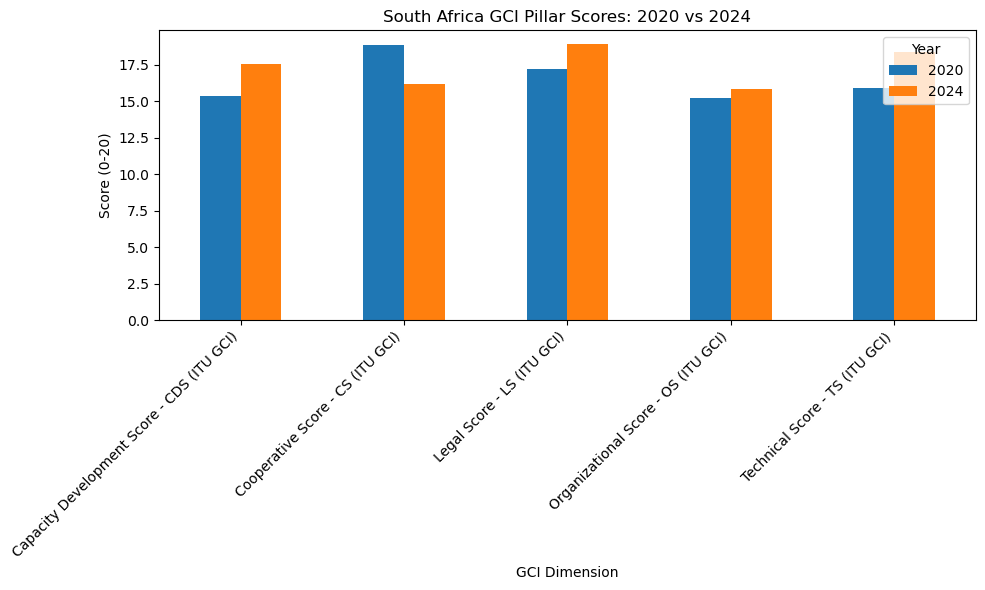

In [26]:


pillar_chart = pillar_summary[
    ["INDICATOR_LABEL", 2020, 2024]
].copy()

pillar_chart = pillar_chart.set_index("INDICATOR_LABEL")


pillar_chart.plot(kind="bar", figsize=(10, 6))

plt.title("South Africa GCI Pillar Scores: 2020 vs 2024")
plt.xlabel("GCI Dimension")
plt.ylabel("Score (0-20)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Year")
plt.tight_layout()
plt.show()

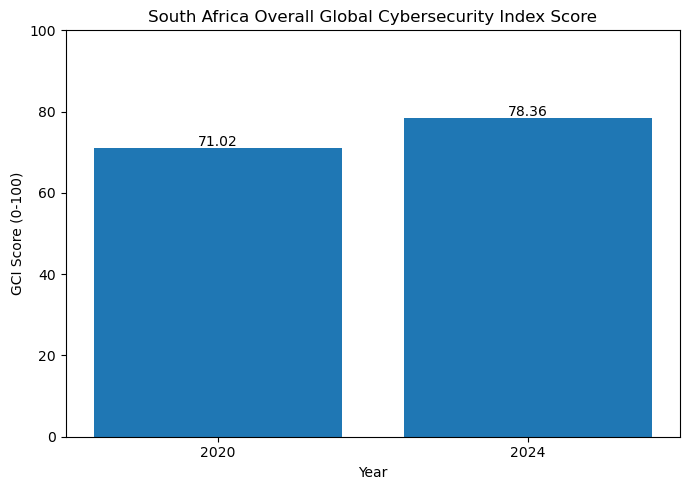

In [27]:

overall_values = [
    overall_gci[2020].iloc[0],
    overall_gci[2024].iloc[0]
]

years = ["2020", "2024"]

plt.figure(figsize=(7, 5))
plt.bar(years, overall_values)

plt.title("South Africa Overall Global Cybersecurity Index Score")
plt.xlabel("Year")
plt.ylabel("GCI Score (0-100)")

for i, value in enumerate(overall_values):
    plt.text(i, value + 0.5, f"{value:.2f}", ha="center")

plt.ylim(0, 100)
plt.tight_layout()
plt.show()

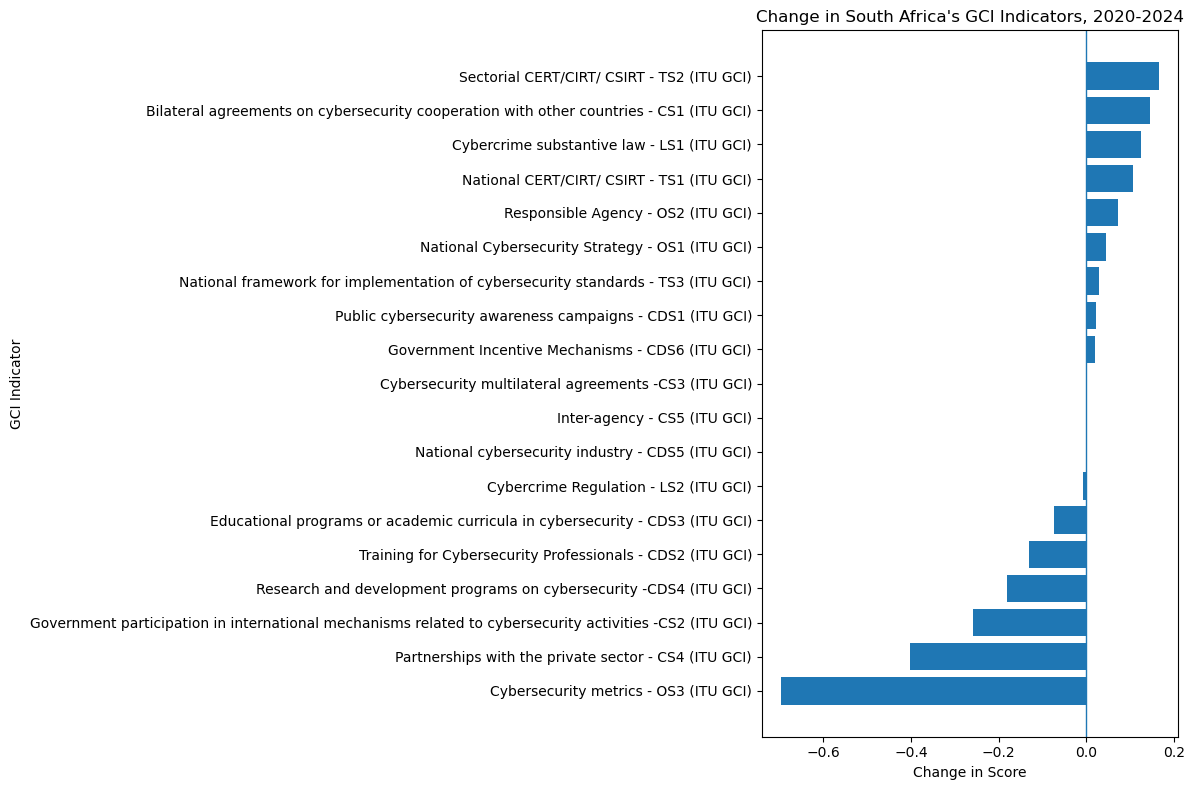

In [28]:

indicator_changes = comparison[
    (comparison["UNIT_MEASURE_LABEL"] == "0-1 scale") &
    (comparison["INDICATOR"] != "ITU_GCI_GCI_OVRL_SCRE")
].dropna(subset=["CHANGE_2020_2024"]).copy()

indicator_changes = indicator_changes.sort_values(
    "CHANGE_2020_2024"
)

plt.figure(figsize=(12, 8))

plt.barh(
    indicator_changes["INDICATOR_LABEL"],
    indicator_changes["CHANGE_2020_2024"]
)

plt.axvline(0, linewidth=1)

plt.title("Change in South Africa's GCI Indicators, 2020-2024")
plt.xlabel("Change in Score")
plt.ylabel("GCI Indicator")

plt.tight_layout()
plt.show()

In [29]:
pillar_display.to_csv("gci_pillar_summary.csv", index=False)

print("GCI pillar summary saved successfully.")

GCI pillar summary saved successfully.


In [30]:
overall_change = overall_gci["CHANGE_2020_2024"].iloc[0]

print("----------------------------------------------")
print("SOUTH AFRICA GCI ANALYSIS SUMMARY")
print("----------------------------------------------")

print(f"\nOverall GCI Score:")
print(f"2020: {overall_gci[2020].iloc[0]:.2f}")
print(f"2024: {overall_gci[2024].iloc[0]:.2f}")
print(f"Change: {overall_change:+.2f} points")

print("\nGCI Pillar Changes:")

for _, row in pillar_display.iterrows():
    print(
        f"{row['INDICATOR_LABEL']}: "
        f"{row[2020]:.2f} → {row[2024]:.2f} "
        f"({row['CHANGE_2020_2024']:+.2f})"
    )

print("\nMain finding:")
print(
    "South Africa's overall GCI score improved between 2020 and 2024, "
    "although the Cooperation pillar declined."
)

----------------------------------------------
SOUTH AFRICA GCI ANALYSIS SUMMARY
----------------------------------------------

Overall GCI Score:
2020: 71.02
2024: 78.36
Change: +7.34 points

GCI Pillar Changes:
Capacity Development Score - CDS (ITU GCI): 15.36 → 17.56 (+2.20)
Cooperative Score - CS (ITU GCI): 18.84 → 16.20 (-2.64)
Legal Score - LS (ITU GCI): 17.18 → 18.90 (+1.72)
Organizational Score - OS (ITU GCI): 15.21 → 15.80 (+0.60)
Technical Score - TS (ITU GCI): 15.90 → 18.38 (+2.48)

Main finding:
South Africa's overall GCI score improved between 2020 and 2024, although the Cooperation pillar declined.


# Member 4 — Data Preparation & Transformation

This section documents the verification, cleaning, transformation and validation of the GCI dataset so that the data is analysis-ready.

**Cleaning principle:** every cleaning decision is documented as **Problem → Action → Reason**.

> **Scope note:** The supplied project files contain the GCI dataset for South Africa. No second source dataset was available in the supplied files, so this notebook does not claim to have verified a second dataset.


In [ ]:
# Member 4: imports and display settings
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_FILE = Path("gci_cleaned.csv")

# If the notebook is being run from a different working directory,
# this searches the current directory for the supplied CSV.
if not DATA_FILE.exists():
    matches = list(Path(".").rglob("gci_cleaned.csv"))
    if matches:
        DATA_FILE = matches[0]

print("Using dataset:", DATA_FILE)


## 1. Load and verify the dataset

The supplied GCI file is semicolon-delimited. The expected structure contains the country reference, indicator information, year and value.


In [ ]:
# Load the source dataset
df_raw = pd.read_csv(DATA_FILE, sep=";")

print("Dataset shape:", df_raw.shape)
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nFirst five records:")
display(df_raw.head())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nMissing values by column:")
display(df_raw.isna().sum().to_frame("missing_count"))


In [ ]:
# Expected schema validation
expected_columns = [
    "REF_AREA",
    "REF_AREA_LABEL",
    "INDICATOR",
    "INDICATOR_LABEL",
    "UNIT_MEASURE_LABEL",
    "YEAR",
    "VALUE"
]

missing_expected = [c for c in expected_columns if c not in df_raw.columns]
unexpected = [c for c in df_raw.columns if c not in expected_columns]

print("Expected columns present:", not missing_expected)
print("Missing expected columns:", missing_expected)
print("Unexpected columns:", unexpected)

assert not missing_expected, f"Missing expected columns: {missing_expected}"


## 2. Standardise column names and text fields

Column names are normalised to uppercase with underscores. Text fields are stripped of unnecessary leading/trailing whitespace. This reduces matching and grouping errors without changing the underlying meaning of the data.


In [ ]:
# Standardise column names
df = df_raw.copy()

df.columns = (
    df.columns
      .str.strip()
      .str.upper()
      .str.replace(r"\\s+", "_", regex=True)
)

# Standardise text fields
text_columns = [
    "REF_AREA",
    "REF_AREA_LABEL",
    "INDICATOR",
    "INDICATOR_LABEL",
    "UNIT_MEASURE_LABEL"
]

for col in text_columns:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.replace(r"\\s+", " ", regex=True)
        )

print("Standardised columns:")
print(df.columns.tolist())


## 3. Standardise country names and country codes

The analysis is specifically for South Africa. The source identifies South Africa with the country code **ZAF**. The country code and label are normalised consistently before filtering.


In [ ]:
# Country standardisation
country_code_map = {
    "ZAF": "ZAF",
    "South Africa": "ZAF"
}

country_label_map = {
    "ZAF": "South Africa",
    "South Africa": "South Africa"
}

df["REF_AREA"] = df["REF_AREA"].map(
    lambda x: country_code_map.get(str(x).strip(), str(x).strip())
)
df["REF_AREA_LABEL"] = df["REF_AREA_LABEL"].map(
    lambda x: country_label_map.get(str(x).strip(), str(x).strip())
)

print("Country codes found:", df["REF_AREA"].dropna().unique().tolist())
print("Country labels found:", df["REF_AREA_LABEL"].dropna().unique().tolist())

# Retain the South Africa records required for this analysis
df = df[(df["REF_AREA"] == "ZAF") | (df["REF_AREA_LABEL"] == "South Africa")].copy()

print("Shape after country filtering:", df.shape)


## 4. Convert data types

`YEAR` is treated as an integer where available and `VALUE` is converted to numeric. Invalid numeric values are converted to missing values rather than silently being treated as zero.


In [ ]:
# Convert YEAR and VALUE to appropriate types
df["YEAR"] = pd.to_numeric(df["YEAR"], errors="coerce").astype("Int64")
df["VALUE"] = pd.to_numeric(df["VALUE"], errors="coerce")

print("Data types after conversion:")
display(df.dtypes.to_frame("dtype"))

print("\nYear values:")
print(sorted(df["YEAR"].dropna().unique().tolist()))

print("\nValue conversion missing count:")
print(df["VALUE"].isna().sum())


## 5. Remove irrelevant records

The supplied analysis concerns South Africa for the available GCI years **2020 and 2024**. Records outside this scope are excluded from the final analysis dataset.

This is a filtering decision rather than deletion of source data: `df_raw` remains available as the original loaded dataset.


In [ ]:
# Scope validation
available_years = sorted(df["YEAR"].dropna().astype(int).unique().tolist())
print("Available years before final scope filter:", available_years)

target_years = [2020, 2024]
df_analysis = df[df["YEAR"].isin(target_years)].copy()

print("Final analysis years:", sorted(df_analysis["YEAR"].dropna().astype(int).unique().tolist()))
print("Analysis dataset shape:", df_analysis.shape)


## 6. Missing-value assessment

Missing values are inspected before any treatment. The project summary identifies one missing value: the **Child Online Protection (TS4)** indicator has a 2020 value but no 2024 value.

The missing 2024 value is retained as missing. It is **not replaced by zero**, because an unavailable observation does not mean that the indicator had a value of zero.


In [ ]:
# Missing-value report
missing_report = (
    df_analysis.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
missing_report["missing_percentage"] = (
    missing_report["missing_count"] / len(df_analysis) * 100
).round(2)

display(missing_report)

# Show rows with missing values
missing_rows = df_analysis[df_analysis.isna().any(axis=1)].copy()
print("Rows containing missing values:", len(missing_rows))
display(missing_rows)


In [ ]:
# Explicit check for the known TS4 missing observation
ts4 = df_analysis[
    (df_analysis["INDICATOR"] == "TS4") |
    (df_analysis["INDICATOR_LABEL"].str.contains("Child Online Protection", case=False, na=False))
].sort_values("YEAR")

print("Child Online Protection (TS4) records:")
display(ts4[[
    "REF_AREA", "REF_AREA_LABEL", "INDICATOR",
    "INDICATOR_LABEL", "YEAR", "VALUE"
]])

print(
    "Decision: retain the missing 2024 observation as NaN; "
    "do not impute it as zero."
)


## 7. Duplicate detection

Duplicates are checked before creating analysis-ready tables. Exact duplicate rows are removed only when they are genuinely duplicated records.

This prevents the same observation from being counted more than once.


In [ ]:
# Check exact duplicate records
duplicate_mask = df_analysis.duplicated(keep=False)
duplicate_rows = df_analysis[duplicate_mask].copy()

print("Number of exact duplicate rows:", len(duplicate_rows))
if len(duplicate_rows):
    display(duplicate_rows)

# Remove exact duplicates only
before = len(df_analysis)
df_analysis = df_analysis.drop_duplicates().copy()
after = len(df_analysis)

print(f"Rows before duplicate removal: {before}")
print(f"Rows after duplicate removal:  {after}")
print(f"Exact duplicates removed:      {before - after}")


## 8. Check for conflicting duplicate keys

An exact duplicate check is not enough. We also check whether the same country–indicator–year combination occurs more than once with different values.

Such conflicts should **not** be automatically deleted because they may represent different measurements or source records.


In [ ]:
# Check logical observation keys
key_columns = ["REF_AREA", "INDICATOR", "YEAR"]

key_counts = (
    df_analysis.groupby(key_columns, dropna=False)
    .size()
    .reset_index(name="record_count")
)

conflicting_keys = key_counts[key_counts["record_count"] > 1]

print("Repeated country-indicator-year keys:", len(conflicting_keys))
if len(conflicting_keys):
    display(conflicting_keys)
    print("Action: inspect these records before removing anything.")
else:
    print("No conflicting repeated country-indicator-year keys found.")


## 9. Descriptive statistics

Descriptive statistics are calculated for the numeric `VALUE` variable and also grouped by year. Because the dataset contains multiple indicators, the grouped statistics provide a clearer view of the distribution within each year.


In [ ]:
# Overall descriptive statistics
descriptive_stats = df_analysis["VALUE"].describe().to_frame("VALUE")
display(descriptive_stats)

# Descriptive statistics by year
descriptive_by_year = (
    df_analysis.groupby("YEAR")["VALUE"]
    .describe()
    .round(2)
)

display(descriptive_by_year)


In [ ]:
# Additional indicator-level descriptive statistics
indicator_stats = (
    df_analysis.groupby(["INDICATOR", "INDICATOR_LABEL"])["VALUE"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        minimum="min",
        maximum="max",
        standard_deviation="std"
    )
    .reset_index()
    .round(2)
)

display(indicator_stats)


## 10. Reshape the data for 2020 vs 2024 comparison

The original dataset is in long format. For comparison, it is reshaped so that each indicator has separate 2020 and 2024 columns. The change is calculated as:

**Change = 2024 value − 2020 value**

If either year's value is missing, the change remains missing.


In [ ]:
# Create analysis-ready comparison table
comparison = (
    df_analysis.pivot_table(
        index=["INDICATOR", "INDICATOR_LABEL"],
        columns="YEAR",
        values="VALUE",
        aggfunc="first"
    )
    .reset_index()
)

# Ensure expected year columns exist
for year in target_years:
    if year not in comparison.columns:
        comparison[year] = np.nan

comparison = comparison.rename(columns={
    2020: "VALUE_2020",
    2024: "VALUE_2024"
})

comparison["CHANGE"] = comparison["VALUE_2024"] - comparison["VALUE_2020"]

comparison = comparison.sort_values("INDICATOR").reset_index(drop=True)

print("Analysis-ready indicator comparison:")
display(comparison)


## 11. Create analysis-ready summary tables

The following tables are designed for direct use in the analysis/report:

- **Indicator comparison:** each indicator's 2020 value, 2024 value and change.
- **Overall GCI:** the overall score comparison.
- **Pillar/dimension summary:** the five major GCI dimensions where the source data supports their identification.


In [ ]:
# Overall GCI table
overall_candidates = comparison[
    comparison["INDICATOR_LABEL"].str.contains(
        r"overall.*GCI|GCI.*score|global cybersecurity index",
        case=False,
        na=False,
        regex=True
    )
].copy()

overall_gci = overall_candidates[[
    "INDICATOR", "INDICATOR_LABEL", "VALUE_2020", "VALUE_2024", "CHANGE"
]].copy()

display(overall_gci)


In [ ]:
# Dimension/pillar summary based on indicator labels
dimension_patterns = {
    "Legal": r"legal",
    "Technical": r"technical",
    "Organizational": r"organiz",
    "Capacity Development": r"capacity",
    "Cooperation": r"cooperat|collabor"
}

dimension_rows = []
for dimension, pattern in dimension_patterns.items():
    matches = comparison[
        comparison["INDICATOR_LABEL"].str.contains(
            pattern, case=False, na=False, regex=True
        )
    ].copy()
    if not matches.empty:
        matches["DIMENSION"] = dimension
        dimension_rows.append(matches)

if dimension_rows:
    dimension_detail = pd.concat(dimension_rows, ignore_index=True)
    pillar_summary = (
        dimension_detail.groupby("DIMENSION", as_index=False)[
            ["VALUE_2020", "VALUE_2024", "CHANGE"]
        ]
        .sum(min_count=1)
        .sort_values("DIMENSION")
    )
else:
    dimension_detail = pd.DataFrame()
    pillar_summary = pd.DataFrame(
        columns=["DIMENSION", "VALUE_2020", "VALUE_2024", "CHANGE"]
    )

print("Dimension summary:")
display(pillar_summary)


## 12. Final validation

Before exporting the analysis-ready data, the following checks are performed:

- South Africa only (`ZAF`)
- years restricted to 2020 and 2024
- expected columns present
- numeric year/value fields
- duplicate records checked
- missing values documented rather than blindly deleted
- comparison table contains 2020, 2024 and calculated change


In [ ]:
# Final validation checks
assert set(df_analysis["REF_AREA"].dropna().unique()).issubset({"ZAF"})
assert set(df_analysis["YEAR"].dropna().astype(int).unique()).issubset(set(target_years))
assert pd.api.types.is_numeric_dtype(df_analysis["VALUE"])
assert not df_analysis.duplicated().any()
assert {"INDICATOR", "INDICATOR_LABEL", "VALUE_2020", "VALUE_2024", "CHANGE"}.issubset(
    comparison.columns
)

print("✓ Country validation passed")
print("✓ Year validation passed")
print("✓ VALUE numeric validation passed")
print("✓ Exact duplicate validation passed")
print("✓ Analysis-ready comparison schema validation passed")
print("\nFinal analysis dataset shape:", df_analysis.shape)


## 13. Member 4 Cleaning Decision Log

| Problem | Action | Reason |
|---|---|---|
| Source file uses semicolon delimiter | Loaded with `sep=';'` | Correctly parses the supplied CSV structure |
| Column names may contain inconsistent formatting | Stripped whitespace and standardised names | Prevents column-reference errors |
| Text fields may contain extra whitespace | Trimmed and normalised whitespace | Improves consistency for matching/grouping |
| Country identification requires consistency | Standardised South Africa to `ZAF` / `South Africa` | Ensures consistent country filtering |
| `YEAR` may not be numeric | Converted to numeric integer type | Required for year filtering and comparison |
| `VALUE` may contain non-numeric values | Converted to numeric; invalid values become missing | Prevents invalid arithmetic |
| Records outside 2020 and 2024 | Excluded from final analysis dataset | These are the years covered by the supplied analysis |
| Missing TS4 2024 value | Retained as missing | Missing/unavailable is not equivalent to zero |
| Exact duplicate records | Removed only if exact duplicates exist | Prevents double counting |
| Repeated logical keys | Checked separately | Conflicting observations should not be deleted automatically |
| Long-format data | Pivoted into 2020/2024 columns | Makes year-to-year comparison straightforward |
| Change calculation | Calculated as 2024 − 2020 | Provides a consistent measure of improvement/decline |

**Important:** No missing value was automatically replaced with zero.


## 14. Export the analysis-ready datasets

The final outputs are saved so they can be used directly in the report or downstream analysis.


In [ ]:
# Export final analysis-ready outputs
df_analysis.to_csv("gci_member4_cleaned.csv", sep=";", index=False)
comparison.to_csv("gci_member4_indicator_comparison.csv", index=False)
descriptive_by_year.to_csv("gci_member4_descriptive_by_year.csv")
indicator_stats.to_csv("gci_member4_indicator_statistics.csv", index=False)
overall_gci.to_csv("gci_member4_overall_gci.csv", index=False)
pillar_summary.to_csv("gci_member4_pillar_summary.csv", index=False)

print("Exported:")
for filename in [
    "gci_member4_cleaned.csv",
    "gci_member4_indicator_comparison.csv",
    "gci_member4_descriptive_by_year.csv",
    "gci_member4_indicator_statistics.csv",
    "gci_member4_overall_gci.csv",
    "gci_member4_pillar_summary.csv",
]:
    print(" -", filename)


## Member 4 conclusion

The dataset has been transformed from the supplied GCI records into analysis-ready tables. The preparation process verifies the structure, standardises fields, restricts the analysis to South Africa and the available 2020/2024 observations, checks duplicates, documents missing values, calculates descriptive statistics, and reshapes the data for direct comparison.

The cleaning process preserves missing information rather than treating unavailable observations as zero. This is particularly important for the missing 2024 Child Online Protection (TS4) observation.
